# PRÁCTICA BACKTESTING AVANZADO

##### Realizado por Mateo Santos

In [1]:
# Importamos las librerías
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pyarrow
import pyarrow.parquet as pq
import time

# Fijamos la semilla
np.random.seed(42)

In [2]:
# Definición de variables globales
capital = 250000
#START_DATE = '2015-01-01'
START_DATE = '2014-01-01'
END_DATE = '2026-01-31'
NUM_ACTIVOS = 20
capital_por_activo = capital/NUM_ACTIVOS

## Notebook 2: EDA (Exploratory Data Analysis) y preparación de los datos

### 2.1. Análisis exploratorio de datos

Para el primer análisis exploratorio de los datos, usaremos los que están en formato largo. Lo que nos interesa aquí es ver la distibución de los activos en función de las variables categóricas existentes:

- **sector**: Indica el sector al que pertenece la empresa.
- **industry**: Indica la industria al que pertenece la empresa.
- **in_sp500**: Indica si la empresa pertenece al S&P500

In [5]:
# 1. Agrupamos incluyendo sector e industry
pertenencia = precios_activos.groupby('security_name').agg({
    'in_sp500': ['sum', 'count'],
    'sector': 'first',      # Ajusta el nombre si en tu dataset es 'sector'
    'industry': 'first' # Ajusta el nombre si es 'industry'
}).reset_index()

# 2. Aplanar los niveles de las columnas (el groupby con agg crea un MultiIndex)
pertenencia.columns = ['security_name', 'sum_in', 'total_days', 'sector', 'industry']

# 3. Definimos las 3 categorías con los nuevos nombres de columna
def clasificar_persistencia(row):
    if row['sum_in'] == row['total_days']:
        return 'Siempre'
    elif row['sum_in'] == 0:
        return 'Nunca'
    else:
        return 'Intermitente'

pertenencia['categoria_sp500'] = pertenencia.apply(clasificar_persistencia, axis=1)

El primer gráfico muestra la proporción de activos que se han mantenido en el S&P 500 durante todo el periodo en el que tenemos datos (desde 1990) comparado con las empresas que han estado a veces y con las que no han estado nunca en el índice.

Como conclusión:
- Hay **298 empresas** que se han mantenido **desde 1990** hasta la actualidad en el **S&P 500**.
- **El resto de empresas** han compaginado periodos en los que se incluían en el S&P 500 con periodos en el que no estaban en él.
- Por extensión, no hay ninguna empresa que no haya estado nunca en el S&P 500.

C:\Users\mateo\AppData\Local\Temp\ipykernel_8624\3113352112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


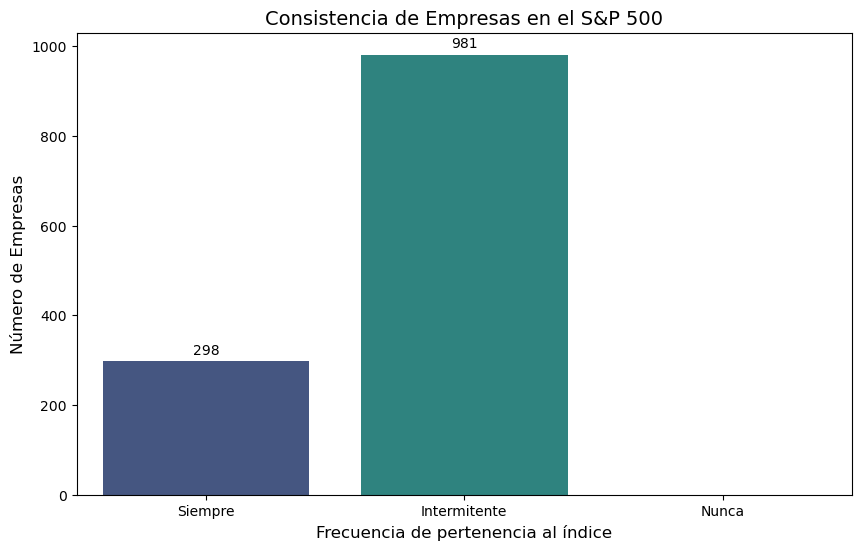

In [6]:
plt.figure(figsize=(10, 6))

# Definimos el orden para que el gráfico sea intuitivo
orden = ['Siempre', 'Intermitente', 'Nunca']

ax = sns.countplot(
    data=pertenencia, 
    x='categoria_sp500', 
    order=orden,
    palette='viridis' # Una paleta distinta para diferenciar del gráfico anterior
)

# Añadimos las etiquetas sobre las barras
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Consistencia de Empresas en el S&P 500', fontsize=14)
# Ajustamos etiquetas para que se entienda el criterio
plt.xlabel('Frecuencia de pertenencia al índice', fontsize=12)
plt.ylabel('Número de Empresas', fontsize=12)

plt.show()

El segundo gráfico muestra el **conteo de empresas por sector**. 

- **Los tres sectores más representados son**:
    - Financiero
    - Industrial
    - Consumo discrecional

- **Los tres sectores menos representados son**:
    - Consumer staples (Bienes de consumo básico)
    - Utilities (Servicios públicos)
    - Real estate (Inmobiliario)

Además, se pueden obtener conclusiones en función de la **presencia de las empresas de cada sector en el S&P 500**. Dicho de otro modo, permite visualizar el **ratio de supervivencia** promedio en cada sector. Destaca:

- **Los tres sectores con un mayor ratio de supervivencia en el S&P 500 son**:
    - Utilities (Servicios públicos)
    - Consumer staples (Consumo básico)
    - Materiales

- **Los tres sectores con un menor ratio de supervivencia en el S&P 500 son**:
    - Consumer discretionary (Consumo discrecional)
    - Information technology (IT)
    - Real estate (Inmobiliario)

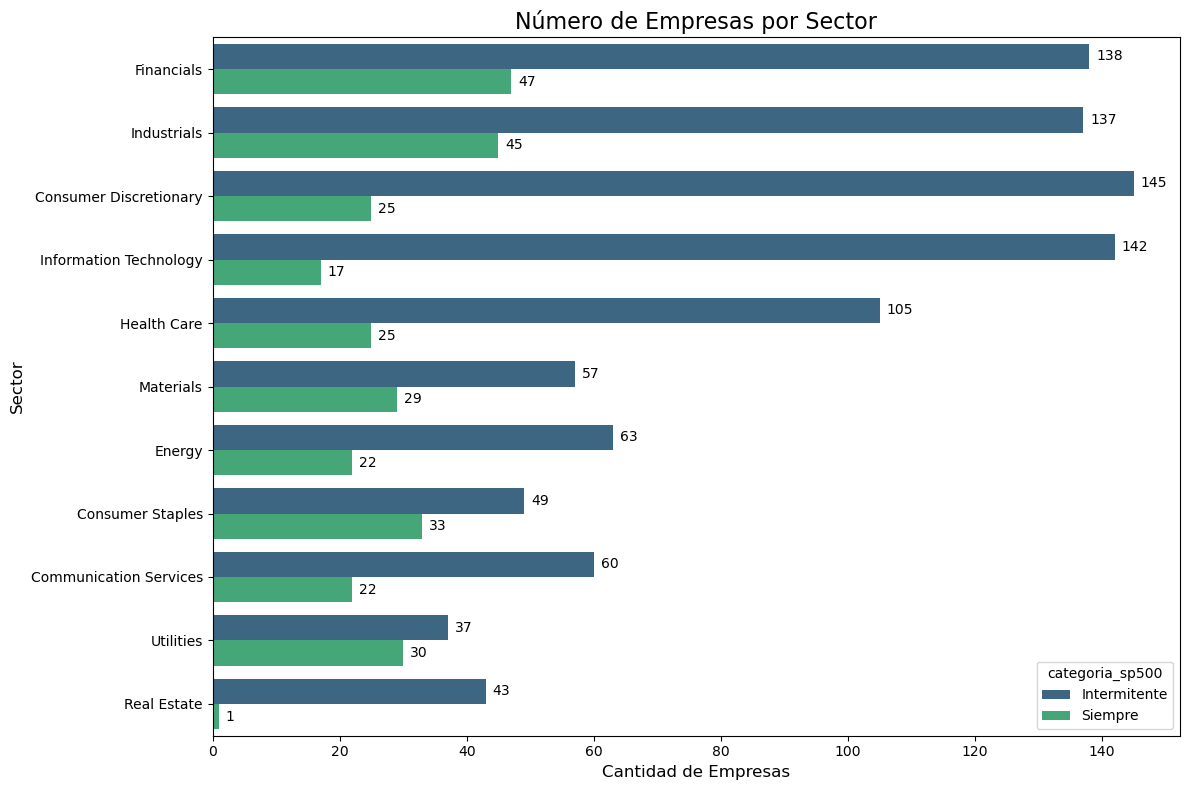

In [7]:
plt.figure(figsize=(12, 8))

# Calculamos el orden
order_sectores = pertenencia['sector'].value_counts().index

# Dibujamos
ax = sns.countplot(
    data=pertenencia, 
    y='sector', 
    palette='viridis',
    hue = 'categoria_sp500',
    order=order_sectores
)

# Añadimos las etiquetas de conteo
for container in ax.containers:
    ax.bar_label(container, padding=5)

plt.title('Número de Empresas por Sector', fontsize=16)
plt.xlabel('Cantidad de Empresas', fontsize=12)
plt.ylabel('Sector', fontsize=12)

plt.tight_layout()
plt.show()

El tercer gráfico muestra el **conteo de empresas por industria**. 

- **Las tres industrias más representadas son**:
    - Energía
    - Banca
    - Seguros

- **Las tres industrias menos representadas son**:
    - Servicios públicos de agua
    - Infraestrucutra de transporte
    - Hotel & Resort RETI (Hoteles)

C:\Users\mateo\AppData\Local\Temp\ipykernel_8624\2552397513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


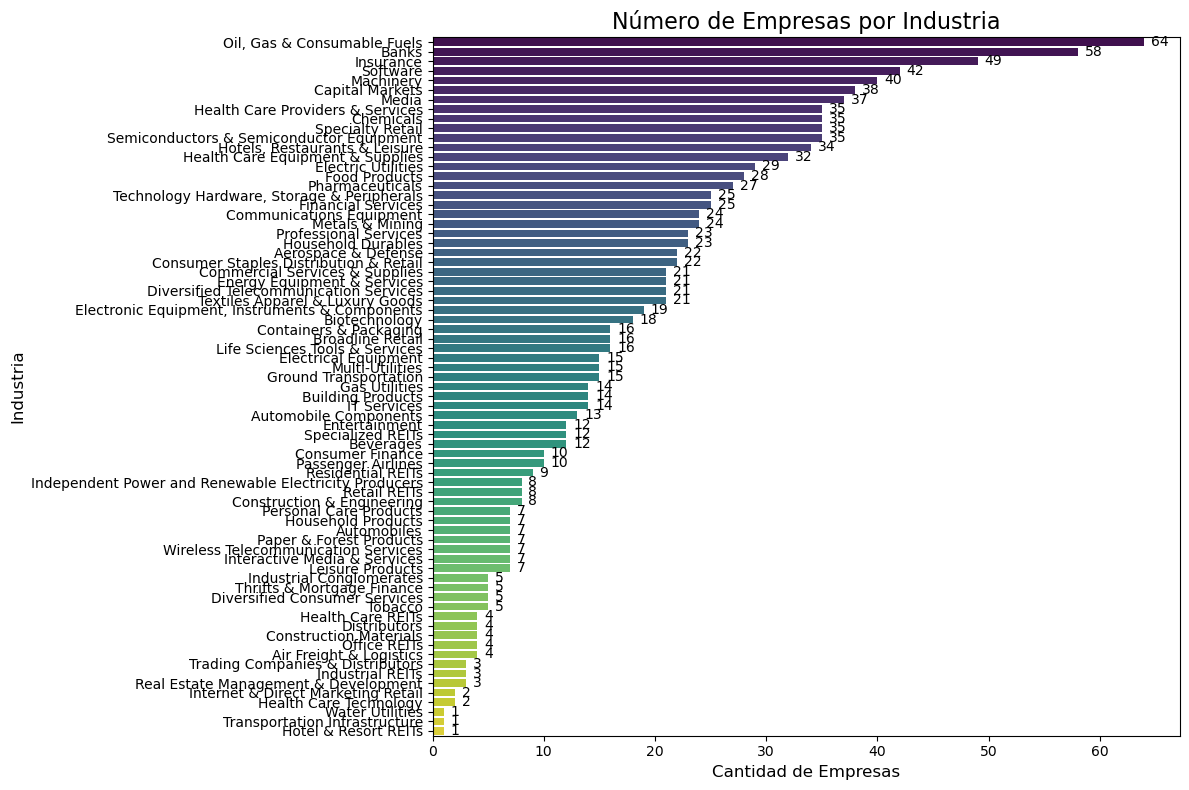

In [8]:
plt.figure(figsize=(12, 8))

# Calculamos el orden
order_sectores = pertenencia['industry'].value_counts().index

# Dibujamos
ax = sns.countplot(
    data=pertenencia, 
    y='industry', 
    palette='viridis', 
    order=order_sectores
)

# Añadimos las etiquetas de conteo
for container in ax.containers:
    ax.bar_label(container, padding=5)

plt.title('Número de Empresas por Industria', fontsize=16)
plt.xlabel('Cantidad de Empresas', fontsize=12)
plt.ylabel('Industria', fontsize=12)

plt.tight_layout()
plt.show()

### 2.2. Preparación de datos

Gracias a la función **`obtener_matrices_control`** filtramos todos los precios de todos los activos que tienen una **vigencia de al menos 13 meses en el S&P 500**. El funcionamiento es el siguiente:

En primer lugar, vemos para cada uno de los días de cotización de cada activo, los días que se encuentre en el S&P 500. Todos los días que esté se le asigna un valor `True` y, en caso contrario, se le asigna el valor `False`.

Por otro lado, para cada mes de cada activo, se comprueba si en los anteriores 13 meses ha estado de forma ininterrumpida en el S&P 500. En caso de que sea así, esa celda tendra un valor `True` y en caso contrario `False`.

Las matrices booleanas permiten operar con las matrices numéricas al tratar los valores `True` como unos y los `False` como ceros.

In [9]:
# Función para generar mascaras de acuerdo con las condiciones de pertenencia y salida del S&P 500 y del mercado
def obtener_matrices_control(df):
    df['date'] = pd.to_datetime(df['date'])
    
    # Esta es la presencia REAL día a día (la que usaremos para vender si salen del SP500)
    presencia_diaria = df.pivot(index='date', columns='symbol', values='in_sp500').fillna(False)
    
    # Lógica de los 13 meses (la que usas para elegir qué comprar)
    presencia_mensual = presencia_diaria.resample('BME').max()
    cumple_13_meses = presencia_mensual.rolling(window=13).sum() == 13
    activos_aptos = cumple_13_meses.reindex(presencia_diaria.index, method='ffill').fillna(False)
    
    return activos_aptos, presencia_diaria

activos_aptos, matriz_sp500 = obtener_matrices_control(precios_activos)

C:\Users\mateo\AppData\Local\Temp\ipykernel_8624\2708021416.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  activos_aptos = cumple_13_meses.reindex(presencia_diaria.index, method='ffill').fillna(False)


A continuación, fijamos como índice a la variable `date`. Finalmente filtramos por las variables de interés:

- **symbol**: Ticker de empresa
- **security_name**: Nombre de empresa
- **sector**: Sector de pertenencia de cada empresa
- **industry**: Industria de pertenencia de cada empresa
- **subsector**: Subsector de pertenencia de cada empresa
- **in_sp500**: Variable categórica que indica la presencia diaria en el S&P 500
- **open**: Precios de apertura
- **close**: Precios de cierre

In [10]:
# Hacemos que la fecha pase a ser índice y borramos la columna fecha
precios_activos['date'] = pd.to_datetime(precios_activos['date'])
precios_activos = precios_activos.set_index('date').sort_index()

# Seleccionamos la fecha correcta y las variables de interés.
# Descartamos las variables (assetid, high, low, volume y unadjusted_close)
lista_variables = ['symbol', 'security_name', 'sector', 'industry', 'subsector', 'in_sp500', 'open', 'close']
precios_activos = precios_activos[lista_variables]

# Filtramos los datos a partir del 2015-01-01
precios = precios_activos.loc[START_DATE:].copy()

La función **`large_to_wide_df`** es la que nos permite pasar los datos de **formato largo a ancho** haciendo uso de la función **`pivot`**. 

Esta función agrupa por `symbol` ya que el Ticker identifica univocamente a cada activo. De este modo, los Tickers pasan a ser las columnas de este nuevo dataframe. Los valores que tomará cada columna serán los precios de cierre en un caso (`precios_close`) y los de apertura en el otro (`precios_open`).

Por último, se filtra por las posiciones válidas `where(activos_aptos)` que habíamos detectado al principio siguiendo la condición de **permanencia de al menos 13 meses en el S&P 500**.

In [11]:
# Función para pasar los datos de formato largo a ancho
def large_to_wide_df(df_large, columns = 'symbol', values = 'close'):
    # Agrupamos los datos en función del ticker del activo (symbol) y seleccionamos los valores values.
    df_wide = df_large.pivot(columns = columns, values = values)
    return df_wide

In [12]:
# Obtenemos los datos en formato ancho para los precios close y open de cada activo
# Filtramos por las fechas en las que los activos han estado al menos 13 meses seguidos en el SP500 -> .where(activos_aptos)
precios_close = large_to_wide_df(precios, columns = 'symbol', values = 'close').where(activos_aptos)
precios_open = large_to_wide_df(precios, columns = 'symbol', values = 'open').where(activos_aptos)

Una vez, ya tenemos los datos en el formato habitual de yfinance (ordenado por filas y columnas **(fechas x activos)**), podemos pasar a calcular los retornos logarítmicos diarios gracias a la función **`get_returns`**.

In [13]:
# Función para obtener los retornos logarítmicos diarios a partir de los precios diarios de cada activo
def get_returns(precios_close):
    returns_close = np.log(precios_close).diff()
    return returns_close.iloc[1:]

In [14]:
# Obtenemos los retornos logarítmicos de los activos diarios sobre los precios de cierre y los de apertura
returns_close = get_returns(precios_close)
returns_open = get_returns(precios_open)

# Tambien para el sp500
returns_sp500 = get_returns(precios_sp500['Close'])

### 2.3. Análisis exploratorio sobre retornos

Tras calcular los retornos se muestran tres gráficos que podrían ser interesantes para estudiar. Como en este caso, el universo de activos seleccionables es demasiado grande, no se pueden obtener conclusiones. En otros casos, sí que sería de utilidad.

**Los tres gráficos siguientes muestran**:
- La evolución de los retornos reales de los primeros 20 activos del dataset.
- La matriz de correlaciones de los activos
- El ratio rentabilidad versus riesgo de los activos

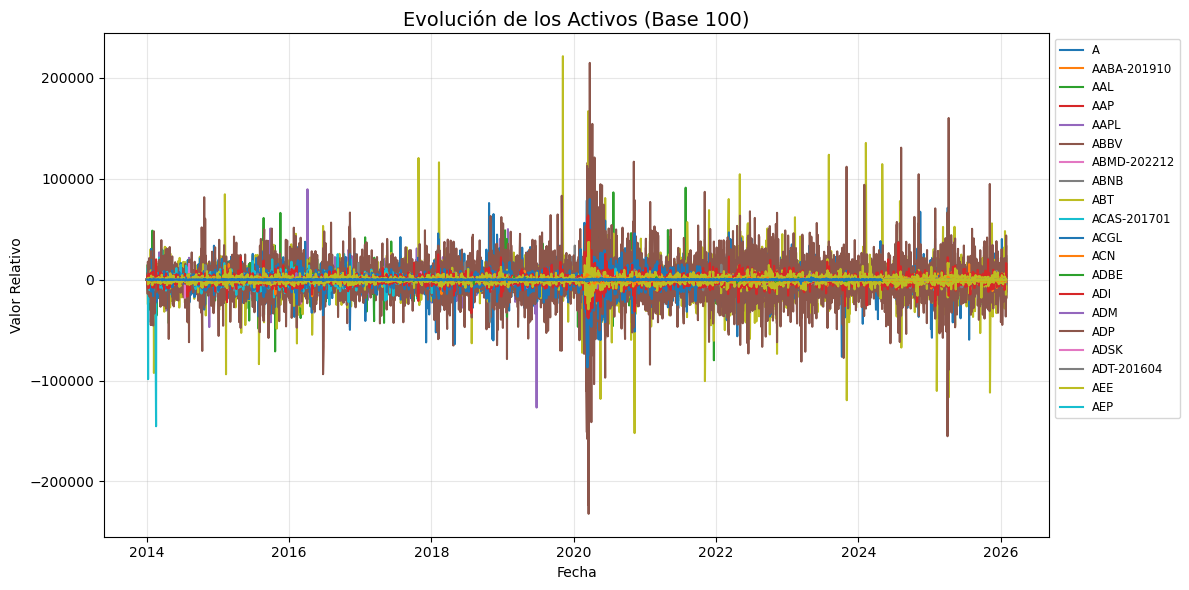

In [15]:
# Normalizamos: (Precio final/ Primer Precio) * 100 -> Wealth index
returns_close_norm = (returns_close / returns_close.iloc[0]) * 100

plt.figure(figsize=(12, 6))
plt.plot(returns_close_norm)

# Añadimos leyenda y etiquetas
plt.legend(returns_close_norm.columns[:20], loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
plt.title('Evolución de los Activos (Base 100)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Valor Relativo')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

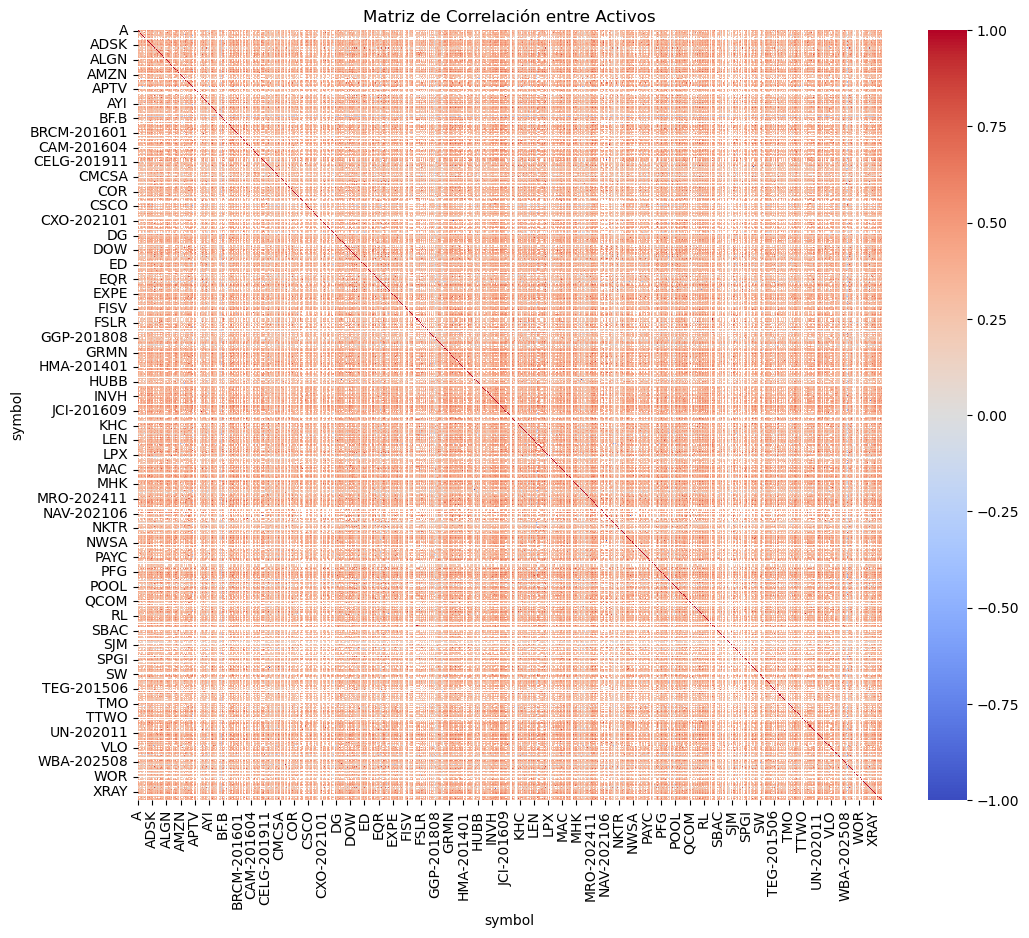

In [16]:
# Calculamos la matriz de correlación de los retornos
corr = returns_close.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación entre Activos')
plt.show()

C:\Users\mateo\AppData\Local\Temp\ipykernel_8624\2011368743.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(activo, (volatilidades[i], rentabilidades[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)


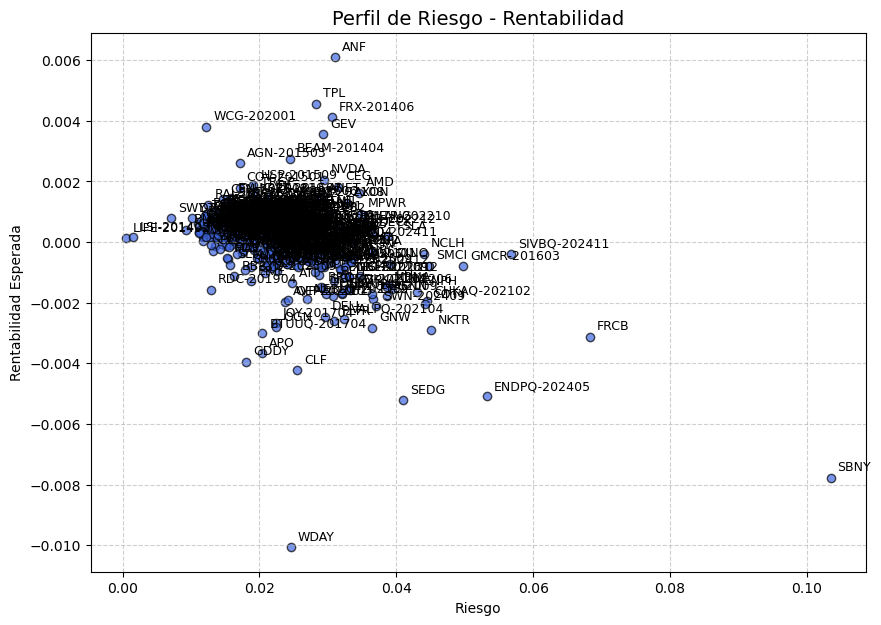

In [17]:
# Obtenemos los vectores de medias y volatilidades. Cada posición corresponde a un activo 
rentabilidades = returns_close.mean()
volatilidades = returns_close.std()

# Creamos el gráfico
plt.figure(figsize=(10, 7))
plt.scatter(volatilidades, rentabilidades, alpha=0.7, c='royalblue', edgecolors='k')

# Añadimos las etiquetas de los activos
for i, activo in enumerate(volatilidades.index):
    plt.annotate(activo, (volatilidades[i], rentabilidades[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)

# Personalización
plt.title('Perfil de Riesgo - Rentabilidad', fontsize=14)
plt.xlabel('Riesgo')
plt.ylabel('Rentabilidad Esperada')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()